In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import scipy as scp

I use the "new" Twisted graphite_LL where I changed the p to q

In [2]:
from twistedGraphite_revised import TwistGraphite_LL

In [23]:
theta = 1.1
model2 = TwistGraphite_LL(theta=theta)


In [24]:
p = 2
q = 1
max_l = 60
x,kz = model2.energy_kz(101,p,q,max_l,True)

301it [01:18,  3.85it/s]


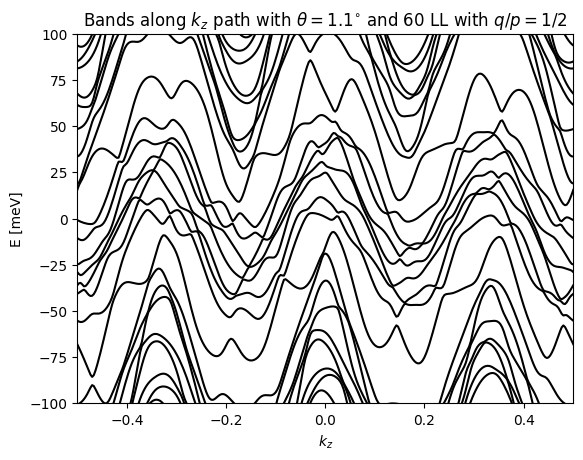

In [ ]:
plt.figure()
plt.plot(kz,x,'k-')
plt.ylim([-100,100])
plt.xlim([kz[0],kz[-1]])
plt.ylabel('E [meV]')
plt.title(rf'Bands along $k_z$ path with $\theta = {theta}^{{\circ}}$ and {max_l} LL with $q/p = ${q}/{p}')
plt.xlabel(r'$k_z$')
#plt.savefig('Bq1p2_dispersion_1_1deg.eps',format ='eps')
plt.show()

The results for different angles give the same results.

In [44]:
def calc_bfield(p,q,theta):
    hbar_e_angstrom2_to_tesla = 65821.2 # hbar/e/angstrom^2 in Teslas
    d=1.42 #angstrom
    theta = np.deg2rad(theta)
    kD=4*np.pi/(3*np.sqrt(3)*d)
    ktheta = kD * 2 * np.sin(theta/2)

    b = np.sqrt(3) / 8 / np.pi * ktheta ** 2 * abs(q)/p * hbar_e_angstrom2_to_tesla

    return b

In [46]:
p = 2
q = 1
theta = 2.1
b = calc_bfield(p,q,theta)
print(b,'Tesla')

8.836505437974063 Tesla


In [ ]:
m_s_angstrom_to_mev = 0.006582  # m/s/angstrom*hbar to mev

## We do butterfly

In [31]:
# def gen_pqlist(max_q,min_alpha =0,max_alpha = 1):
#     """
#     Generate a alist of p,q between min_alpha and max_alpha with alpha = phi_0/phi = p/q
#     Don't put a to big value of q since the then the matrix will be huge
#     So max_q is max denominator
#     """
#     plist = np.array([])
#     qlist = np.array([])
#     for q in range(1, max_q + 1):
#         for p in range(int(max(np.ceil(q * min_alpha), 1)), int(np.floor(q * max_alpha)) + 1):
#             if np.gcd(p, q) == 1:
#                 plist = np.append(plist, p)
#                 qlist = np.append(qlist, q)
#     pqlist = plist / qlist
#     s_ind = np.argsort(pqlist)
#     plist = plist[s_ind]
#     qlist = qlist[s_ind]
#     pqlist = pqlist[s_ind]
#     return plist, qlist, pqlist


In [4]:
from math import gcd

In [14]:
max_l = 40
kz = 0

In [15]:
q_max=40
ee = []
for p in tqdm(range(1,q_max+1)):
    div=gcd(q_max,p)
    _,h = model2.hamiltonian(p = p//div,q = q_max//div, kz = kz ,max_l = max_l)
    ei = np.linalg.eigvalsh(h)
    ee.append(ei)

100%|██████████| 40/40 [06:15<00:00,  9.38s/it]


40it [00:00, 655.20it/s]


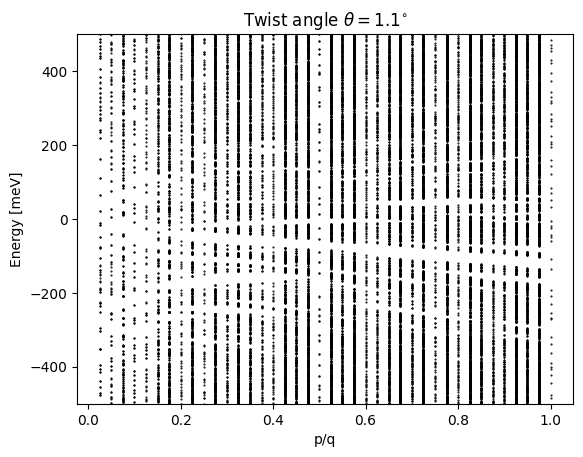

In [16]:
plt.figure
for i,ei in tqdm(enumerate(ee)):
    plt.plot((i+1)*np.ones_like(ei)/q_max,ei,'.k',markersize = 1)
plt.ylim(np.array([-500,500]))
# plt.xlim([qplist[0],qplist[-1]])
plt.title(rf'Twist angle $\theta = {theta}^{{\circ}}$')
plt.xlabel('p/q')
plt.ylabel('Energy [meV]')
#plt.savefig('butterfly_graphite11_ver3.eps',format ='eps')
plt.show()